# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
# Standard libraries for deep learning and data handling
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
# ── Student Customisation Task 1: Replace sample corpus with custom paragraph ──
# Custom ocean/marine science themed corpus
text_data = '''
the ocean is vast and full of mysteries waiting to be discovered
marine life adapts to changing environments through evolution
coral reefs are ecosystems of extraordinary biological diversity
ocean currents regulate the global climate and temperature
deep sea creatures survive extreme pressure and darkness
scientists explore underwater caves to find unknown species
the blue whale is the largest animal on the planet
ocean pollution threatens biodiversity and marine food chains
sustainable fishing practices protect the long-term health of oceans
marine biology connects ecology chemistry and evolutionary science
'''

print(text_data)


the ocean is vast and full of mysteries waiting to be discovered
marine life adapts to changing environments through evolution
coral reefs are ecosystems of extraordinary biological diversity
ocean currents regulate the global climate and temperature
deep sea creatures survive extreme pressure and darkness
scientists explore underwater caves to find unknown species
the blue whale is the largest animal on the planet
ocean pollution threatens biodiversity and marine food chains
sustainable fishing practices protect the long-term health of oceans
marine biology connects ecology chemistry and evolutionary science



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
# Build vocabulary from the corpus text
vocab_builder = Tokenizer()
vocab_builder.fit_on_texts([text_data])
vocab_size = len(vocab_builder.word_index) + 1
print("Vocabulary size:", vocab_size)

# Build n-gram sequences using a sliding window approach
all_sequences = []
for sent in text_data.split('\n'):
    encoded = vocab_builder.texts_to_sequences([sent])[0]
    for j in range(1, len(encoded)):
        all_sequences.append(encoded[:j+1])

# Pad all sequences to the same length (pre-padding)
seq_length = max(len(s) for s in all_sequences)
padded     = pad_sequences(all_sequences, maxlen=seq_length, padding='pre')

# Split into input features and target labels
features = padded[:, :-1]
labels   = padded[:, -1]

print("Features shape:", features.shape)
print("Labels shape  :", labels.shape)

Vocabulary size: 71
Features shape: (78, 11)
Labels shape  : (78,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
# ── Student Customisation Tasks 2, 3, 4 applied here ──
# Embedding size increased to 100, hidden units increased to 128, epochs = 200

rnn_net = Sequential([
    Embedding(vocab_size, 100, input_length=seq_length-1),   # Task 2: embedding 50 → 100
    SimpleRNN(128),                                            # Task 3: units 64 → 128
    Dense(vocab_size, activation='softmax')
])

# Same Adam optimizer configuration used across all models
rnn_net.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

# Task 4: training for 200 epochs
rnn_log = rnn_net.fit(features, labels, epochs=200, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
# LSTM model with same hyperparameter settings as SimpleRNN
lstm_net = Sequential([
    Embedding(vocab_size, 100, input_length=seq_length-1),
    LSTM(128),
    Dense(vocab_size, activation='softmax')
])

lstm_net.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

lstm_log = lstm_net.fit(features, labels, epochs=200, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
# GRU model — lighter than LSTM with comparable performance
gru_net = Sequential([
    Embedding(vocab_size, 100, input_length=seq_length-1),
    GRU(128),
    Dense(vocab_size, activation='softmax')
])

gru_net.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    metrics=['accuracy']
)

gru_log = gru_net.fit(features, labels, epochs=200, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

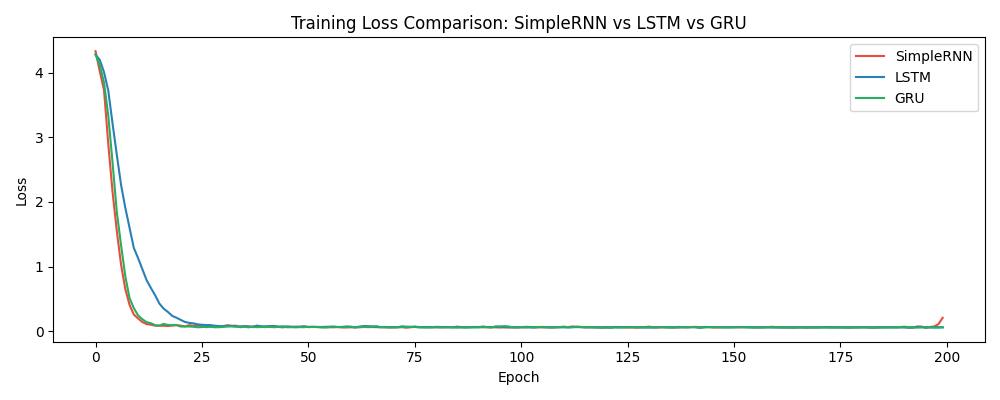

In [7]:
# Single graph comparing training loss curves of all three architectures
plt.figure(figsize=(10, 4))
plt.plot(rnn_log.history['loss'],  label='SimpleRNN', color='#e74c3c')
plt.plot(lstm_log.history['loss'], label='LSTM',      color='#2980b9')
plt.plot(gru_log.history['loss'],  label='GRU',       color='#27ae60')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison: SimpleRNN vs LSTM vs GRU")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
# Generates 'n_words' words appended to the given seed phrase
def generate_text(model, seed, n_words=10):
    result = seed
    for _ in range(n_words):
        # Encode and pad the current sequence
        toks = vocab_builder.texts_to_sequences([result])[0]
        toks = pad_sequences([toks], maxlen=seq_length-1, padding='pre')

        # Pick the highest-probability next word using argmax
        pred_idx  = np.argmax(model.predict(toks, verbose=0), axis=-1)[0]

        # Map predicted index back to word
        next_word = ""
        for word, idx in vocab_builder.word_index.items():
            if idx == pred_idx:
                next_word = word
                break

        result += " " + next_word
    return result

## 🧪 Generate Text Samples

In [9]:
# ── Student Customisation Task 5: Generate 10 words ──
# Same seed phrase used for all three models so results are directly comparable
seed_phrase = "the ocean"

print("RNN :", generate_text(rnn_net,  seed_phrase, 10))
print("LSTM:", generate_text(lstm_net, seed_phrase, 10))
print("GRU :", generate_text(gru_net,  seed_phrase, 10))

RNN : the ocean currents regulate the global climate and temperature food chains underwater
LSTM: the ocean is vast and full of mysteries waiting to be discovered
GRU : the ocean is vast and full of mysteries waiting to be discovered


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**